In [1]:
# ALWAYS RUN THIS FIRST!
import os
import sys
from pathlib import Path

NOTEBOOK_DIR = Path("/rsrch9/home/plm/idso_fa1_pathology/codes/yshokrollahi/vitamin-p-latest")
os.chdir(NOTEBOOK_DIR)
sys.path.insert(0, str(NOTEBOOK_DIR))

print(f"✅ Working directory: {os.getcwd()}")


✅ Working directory: /rsrch9/home/plm/idso_fa1_pathology/codes/yshokrollahi/vitamin-p-latest


In [2]:
# Cell 3: Import and create dataloaders
from dataset import Config, create_dataloaders

# Just use the correct relative path from your working directory
config = Config("configs/training/config_fold32.yaml")  # Note: "configs" not "config"
config.print_config()

train_loader, val_loader, test_loader = create_dataloaders(config)
print("\n✅ Ready to use!")

✅ CRC Dataset Package v1.0.0 loaded
CRC DATASET CONFIGURATION
Config File: configs/training/config_fold32.yaml
Zarr Base: /rsrch9/home/plm/idso_fa1_pathology/TIER2/yasin-vitaminp/ORION-CRC/zarr_data
Cache: Disabled
Strategy: memory

📊 Data Splits:
  Train: 54 samples
  Val: 17 samples
  Test: 15 samples

🔄 DataLoader:
  Batch Size: 4
  Num Workers: 16
  Pin Memory: True

🎨 Augmentation:
  Training: True
  Probability: 1.0

🎯 HV Maps:
  Generate: True
  Method: pannuke
  HE Nuclei: True
  HE Cells: True
  MIF Nuclei: True
  MIF Cells: True

🔍 Filtering:
  Min Instances: 0
  Filter Empty: True

CREATING DATALOADERS
Strategy: memory
Use Cache: False
Batch Size: 4
Num Workers: 16
Train split: 35 CRC + 7 Xenium + 1 TissueNet + 1 PanNuke + 1 Lizard + 1 MoNuSeg + 1 MoNuSAC + 1 TNBC + 1 NuInsSeg + 1 CryoNuSeg + 1 BC + 1 CoNSeP + 1 Kumar + 1 CPM17
Val   split: 3 CRC + 2 Xenium + 1 TissueNet + 1 PanNuke + 1 Lizard + 1 MoNuSeg + 1 MoNuSAC + 1 TNBC + 1 NuInsSeg + 1 CryoNuSeg + 1 BC + 1 CoNSeP + 1 

In [6]:
import zarr
import numpy as np
import pandas as pd
import os
from joblib import Parallel, delayed
from tqdm import tqdm

# 1. Define your dataset paths
DATASET_PATHS = {
    "crc": "/rsrch9/home/plm/idso_fa1_pathology/TIER2/yasin-vitaminp/ORION-CRC/zarr_data",
    "xenium": "/rsrch9/home/plm/idso_fa1_pathology/TIER2/yasin-vitaminp/Xenium/zarr_data",
    "tissuenet": "/rsrch9/home/plm/idso_fa1_pathology/TIER2/yasin-vitaminp/tissuenet/zarr_data",
    "pannuke": "/rsrch9/home/plm/idso_fa1_pathology/TIER2/yasin-vitaminp/pannuke/zarr_data",
    "lizard": "/rsrch9/home/plm/idso_fa1_pathology/TIER2/yasin-vitaminp/lizard/zarr_data",
    "monuseg": "/rsrch9/home/plm/idso_fa1_pathology/TIER2/yasin-vitaminp/monuseg/zarr_data",
    "tnbc": "/rsrch9/home/plm/idso_fa1_pathology/TIER2/yasin-vitaminp/tnbc/zarr_data",
    "nuinsseg": "/rsrch9/home/plm/idso_fa1_pathology/TIER2/yasin-vitaminp/nuinsseg/zarr_data",
    "cryonuseg": "/rsrch9/home/plm/idso_fa1_pathology/TIER2/yasin-vitaminp/cryonuseg/zarr_data",
    "bc": "/rsrch9/home/plm/idso_fa1_pathology/TIER2/yasin-vitaminp/bcdata/zarr_data",
    "consep": "/rsrch9/home/plm/idso_fa1_pathology/TIER2/yasin-vitaminp/consep/zarr_data",
    "monusac": "/rsrch9/home/plm/idso_fa1_pathology/TIER2/yasin-vitaminp/monusac/zarr_data",
    "kumar": "/rsrch9/home/plm/idso_fa1_pathology/TIER2/yasin-vitaminp/kumar/zarr_data",
    "cpm17": "/rsrch9/home/plm/idso_fa1_pathology/TIER2/yasin-vitaminp/cpm17/zarr_data"
}

# --- Helper Functions ---
def safe_count_zarr(path):
    """Safely counts unique non-zero instances in a Zarr array."""
    if not os.path.exists(path):
        return 0
    try:
        # Open read-only
        arr = zarr.open(path, mode='r')
        # Load entire array to RAM (fastest for batch processing)
        data = arr[:] 
        
        count = 0
        # Iterate tiles
        for i in range(data.shape[0]):
            tile = data[i]
            if tile.max() == 0: continue
            
            # Fast unique check
            u = len(np.unique(tile))
            if 0 in tile: u -= 1
            count += u
        return count
    except Exception:
        return 0

def get_tile_count(path):
    """Detects number of tiles by checking common image keys."""
    # Check for direct images (Flat)
    p1 = os.path.join(path, 'images.zarr')
    if os.path.exists(p1):
        try: return zarr.open(p1, mode='r').shape[0]
        except: pass
        
    # Check for HE images (Nested)
    p2 = os.path.join(path, 'he', 'images.zarr')
    if os.path.exists(p2):
        try: return zarr.open(p2, mode='r').shape[0]
        except: pass
        
    # Check for MIF images (Nested)
    p3 = os.path.join(path, 'mif', 'images.zarr')
    if os.path.exists(p3):
        try: return zarr.open(p3, mode='r').shape[0]
        except: pass

    return 0

# --- Worker Function ---
def analyze_sample(dataset_group, sample_name, sample_path):
    stats = {
        'Dataset': dataset_group,
        'Sample': sample_name,
        'Tiles': 0,
        'HE Nuclei': 0, 'HE Cells': 0,
        'MIF Nuclei': 0, 'MIF Cells': 0
    }
    
    # 1. DATASETS WITH SUB-FOLDERS (ROIs)
    # TissueNet, PanNuke, MoNuSeg, TNBC, MoNuSAC
    if dataset_group in ['tissuenet', 'pannuke', 'monuseg', 'tnbc', 'monusac']:
        try:
            # Iterate over sub-folders (ROIs) inside the sample folder
            sub_folders = [f for f in os.listdir(sample_path) if os.path.isdir(os.path.join(sample_path, f))]
            
            for sub in sub_folders:
                sub_path = os.path.join(sample_path, sub)
                stats['Tiles'] += get_tile_count(sub_path)
                
                if dataset_group == 'tissuenet':
                    # TissueNet has masks in mif/ folder
                    stats['MIF Nuclei'] += safe_count_zarr(os.path.join(sub_path, 'mif', 'nuclei_masks.zarr'))
                    stats['MIF Cells']  += safe_count_zarr(os.path.join(sub_path, 'mif', 'cell_masks.zarr'))
                else:
                    # Others have masks in root of subfolder
                    stats['HE Nuclei'] += safe_count_zarr(os.path.join(sub_path, 'nuclei_masks.zarr'))
                    
        except Exception as e:
            pass 

    # 2. FLAT DATASETS (Direct Zarrs)
    # Lizard, NuInsSeg, BC, etc.
    elif dataset_group in ['lizard', 'nuinsseg', 'cryonuseg', 'bc', 'consep', 'kumar', 'cpm17']:
        stats['Tiles'] = get_tile_count(sample_path)
        stats['HE Nuclei'] = safe_count_zarr(os.path.join(sample_path, 'nuclei_masks.zarr'))
        
    # 3. DUAL MODALITY (CRC, Xenium)
    # Has he/ and mif/ subdirectories
    else:
        stats['Tiles'] = get_tile_count(sample_path)
        stats['HE Nuclei']  += safe_count_zarr(os.path.join(sample_path, 'he', 'nuclei_masks.zarr'))
        stats['HE Cells']   += safe_count_zarr(os.path.join(sample_path, 'he', 'cell_masks.zarr'))
        stats['MIF Nuclei'] += safe_count_zarr(os.path.join(sample_path, 'mif', 'nuclei_masks.zarr'))
        stats['MIF Cells']  += safe_count_zarr(os.path.join(sample_path, 'mif', 'cell_masks.zarr'))

    return stats

# --- Main Execution ---
def run_scan():
    tasks = []
    print(f"{'='*60}")
    print(f"{'SEARCHING FOR SAMPLES':^60}")
    print(f"{'='*60}")
    
    # Discovery Phase
    for ds_name, ds_root in DATASET_PATHS.items():
        if not os.path.exists(ds_root):
            print(f"❌ Missing Path: {ds_root}")
            continue
            
        try:
            # Use os.listdir instead of zarr.open_group
            # Filter for directories that don't start with '.'
            samples = [
                s for s in os.listdir(ds_root) 
                if os.path.isdir(os.path.join(ds_root, s)) and not s.startswith('.')
            ]
            
            print(f"   📂 {ds_name.upper()}: Found {len(samples)} samples")
            
            for s in samples:
                tasks.append((ds_name, s, os.path.join(ds_root, s)))
                
        except Exception as e:
            print(f"   ⚠️ Error scanning {ds_name}: {e}")

    print(f"\n🚀 Processing {len(tasks)} samples on 64 cores...")
    
    # Parallel Phase
    results = Parallel(n_jobs=64, verbose=5)(
        delayed(analyze_sample)(ds, samp, path) for ds, samp, path in tasks
    )
    
    # Aggregation Phase
    df = pd.DataFrame(results)
    
    if not df.empty:
        # Determine Modality
        def get_mod(row):
            he = (row['HE Nuclei'] > 0) or (row['HE Cells'] > 0)
            mif = (row['MIF Nuclei'] > 0) or (row['MIF Cells'] > 0)
            if he and mif: return 'Mixed (HE+MIF)'
            if mif: return 'MIF Only'
            if he: return 'HE Only'
            return 'No Annotations'

        df['Modality'] = df.apply(get_mod, axis=1)
        
        # Sort and Reorder
        cols = ['Dataset', 'Sample', 'Modality', 'Tiles', 'HE Nuclei', 'HE Cells', 'MIF Nuclei', 'MIF Cells']
        df = df[cols].sort_values(['Dataset', 'Sample'])
        
        # Print Summary
        print("\n\n📊 DATASET STATISTICS")
        pd.set_option('display.max_rows', None)
        print(df)
        
        # Grouped Summary
        print("\n\n📦 SUMMARY BY DATASET")
        print(df.groupby('Dataset')[['Tiles', 'HE Nuclei', 'HE Cells', 'MIF Nuclei', 'MIF Cells']].sum())

        df.to_csv("dataset_statistics_final.csv", index=False)
        print("\n✅ Saved detailed stats to 'dataset_statistics_final.csv'")
    else:
        print("❌ No data found.")

if __name__ == "__main__":
    run_scan()

                   SEARCHING FOR SAMPLES                    
   📂 CRC: Found 41 samples
   📂 XENIUM: Found 9 samples
   📂 TISSUENET: Found 3 samples
   📂 PANNUKE: Found 3 samples
   📂 LIZARD: Found 3 samples
   📂 MONUSEG: Found 3 samples
   📂 TNBC: Found 3 samples
   📂 NUINSSEG: Found 3 samples
   📂 CRYONUSEG: Found 3 samples
   📂 BC: Found 3 samples
   📂 CONSEP: Found 3 samples
   📂 MONUSAC: Found 3 samples
   📂 KUMAR: Found 3 samples
   📂 CPM17: Found 3 samples

🚀 Processing 86 samples on 64 cores...


[Parallel(n_jobs=64)]: Using backend LokyBackend with 64 concurrent workers.
[Parallel(n_jobs=64)]: Done  13 out of  86 | elapsed:    8.1s remaining:   45.3s
[Parallel(n_jobs=64)]: Done  31 out of  86 | elapsed:   12.5s remaining:   22.2s
[Parallel(n_jobs=64)]: Done  49 out of  86 | elapsed:   17.4s remaining:   13.2s
[Parallel(n_jobs=64)]: Done  67 out of  86 | elapsed:   23.9s remaining:    6.8s




📊 DATASET STATISTICS
      Dataset           Sample        Modality  Tiles  HE Nuclei  HE Cells  \
71         bc          bc_test         HE Only     66       9065         0   
72         bc         bc_train         HE Only    347      48530         0   
73         bc           bc_val         HE Only     38       5620         0   
74     consep      consep_test         HE Only     56       9620         0   
75     consep     consep_train         HE Only    100      15585         0   
76     consep       consep_val         HE Only      8       1404         0   
83      cpm17       cpm17_test         HE Only     71       7587         0   
84      cpm17      cpm17_train         HE Only     52       5400         0   
85      cpm17        cpm17_val         HE Only      1         90         0   
0         crc            CRC01  Mixed (HE+MIF)     36       5473      5319   
1         crc            CRC02  Mixed (HE+MIF)     75      14193     14045   
2         crc            CRC03  Mixed (HE

[Parallel(n_jobs=64)]: Done  86 out of  86 | elapsed:  4.1min finished


📂 Loading results from dataset_statistics_final.csv...

                          DATASET SUMMARY (Aggregated)                          
  Dataset  Sub-groups  Tiles  HE Nuclei  HE Cells  MIF Nuclei  MIF Cells  Total Annotations       Modality
tissuenet           3   3691          0         0     1343719    1427726            2771445       MIF Only
      crc          41   3337     611264    599043      611264     599043            2420614 Mixed (HE+MIF)
   xenium           9   1909     189580    181844      189580     181844             742848 Mixed (HE+MIF)
   lizard           3   1395     625700         0           0          0             625700        HE Only
  pannuke           3   1976     189257         0           0          0             189257        HE Only
  monusac           3    903      81422         0           0          0              81422        HE Only
       bc           3    451      63215         0           0          0              63215        HE Only
    kum

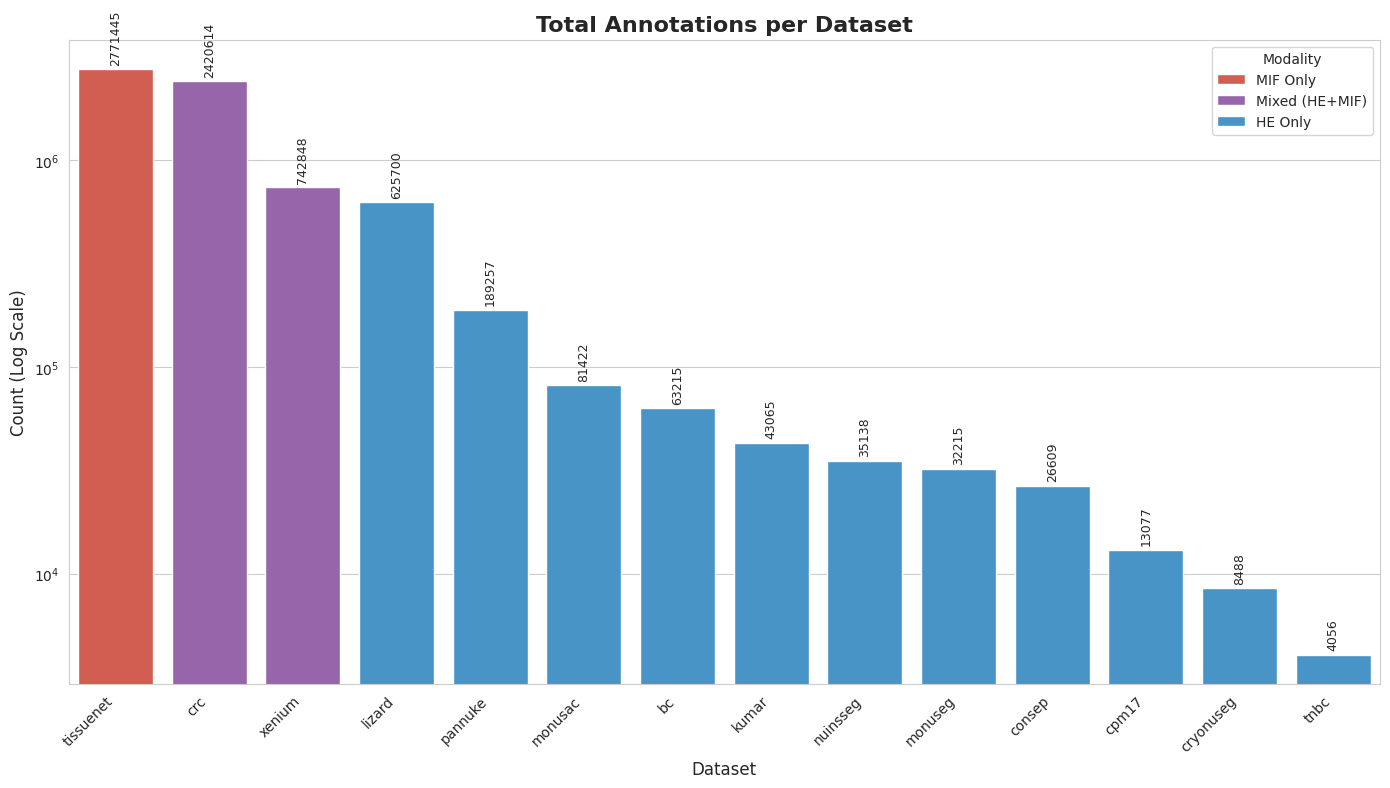

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def summarize_results(csv_path="dataset_statistics_final.csv"):
    print(f"📂 Loading results from {csv_path}...")
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print("❌ CSV file not found. Please wait for the scanning script to finish.")
        return

    # 1. AGGREGATE SPLITS (Sum train/val/test for external datasets)
    # We group by 'Dataset' (e.g., 'tissuenet', 'crc') and sum the counts
    summary = df.groupby('Dataset').agg({
        'Sample': 'count',              # Count how many sub-folders/splits
        'Tiles': 'sum',                 # Sum total tiles
        'HE Nuclei': 'sum',
        'HE Cells': 'sum',
        'MIF Nuclei': 'sum',
        'MIF Cells': 'sum'
    }).reset_index()

    # Rename 'Sample' column to 'Sub-groups' for clarity
    summary = summary.rename(columns={'Sample': 'Sub-groups'})

    # 2. ADD TOTAL ANNOTATIONS COLUMN
    summary['Total Annotations'] = (
        summary['HE Nuclei'] + summary['HE Cells'] + 
        summary['MIF Nuclei'] + summary['MIF Cells']
    )

    # 3. DETERMINING DOMINANT MODALITY (for coloring)
    def get_modality(row):
        he = (row['HE Nuclei'] > 0) or (row['HE Cells'] > 0)
        mif = (row['MIF Nuclei'] > 0) or (row['MIF Cells'] > 0)
        if he and mif: return 'Mixed (HE+MIF)'
        if mif: return 'MIF Only'
        if he: return 'HE Only'
        return 'Empty'
    
    summary['Modality'] = summary.apply(get_modality, axis=1)

    # 4. DISPLAY TABLE
    # Sort by Total Annotations
    summary = summary.sort_values('Total Annotations', ascending=False)
    
    print("\n" + "="*80)
    print(f"{'DATASET SUMMARY (Aggregated)':^80}")
    print("="*80)
    # Format large numbers with commas
    pd.options.display.float_format = '{:,.0f}'.format
    print(summary.to_string(index=False))

    # 5. VISUALIZATION
    plt.figure(figsize=(14, 8))
    sns.set_style("whitegrid")
    
    # Bar chart of Total Annotations
    ax = sns.barplot(
        data=summary, 
        x='Dataset', 
        y='Total Annotations', 
        hue='Modality', 
        dodge=False,
        palette={'Mixed (HE+MIF)': '#9b59b6', 'HE Only': '#3498db', 'MIF Only': '#e74c3c', 'Empty': 'gray'}
    )
    
    plt.title('Total Annotations per Dataset', fontsize=16, fontweight='bold')
    plt.xlabel('Dataset', fontsize=12)
    plt.ylabel('Count (Log Scale)', fontsize=12)
    plt.yscale('log') # Log scale because counts vary wildly
    plt.xticks(rotation=45, ha='right')
    
    # Add value labels on top of bars
    for i in ax.containers:
        ax.bar_label(i, fmt='%d', padding=3, rotation=90, fontsize=9)
        
    plt.tight_layout()
    plt.show()

# Run the summary
summarize_results()

## heatmap

In [8]:
import zarr
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import Parallel, delayed
from tqdm import tqdm

# 1. Define your dataset path (START WITH ONE)
DATASET_PATHS = {
    "pannuke": "/rsrch9/home/plm/idso_fa1_pathology/TIER2/yasin-vitaminp/pannuke/zarr_data",
}

# --- Helper Functions ---
def safe_count_zarr(path):
    """Safely counts unique non-zero instances in a Zarr array."""
    if not os.path.exists(path):
        return 0
    try:
        arr = zarr.open(path, mode='r')
        data = arr[:] 
        
        count = 0
        for i in range(data.shape[0]):
            tile = data[i]
            if tile.max() == 0: 
                continue
            
            u = len(np.unique(tile))
            if 0 in tile: 
                u -= 1
            count += u
        return count
    except Exception:
        return 0

def get_tile_count(path):
    """Detects number of tiles by checking common image keys."""
    p1 = os.path.join(path, 'images.zarr')
    if os.path.exists(p1):
        try: 
            return zarr.open(p1, mode='r').shape[0]
        except: 
            pass
        
    p2 = os.path.join(path, 'he', 'images.zarr')
    if os.path.exists(p2):
        try: 
            return zarr.open(p2, mode='r').shape[0]
        except: 
            pass
        
    p3 = os.path.join(path, 'mif', 'images.zarr')
    if os.path.exists(p3):
        try: 
            return zarr.open(p3, mode='r').shape[0]
        except: 
            pass

    return 0

# --- Worker Function ---
def analyze_sample(dataset_group, sample_name, sample_path):
    stats = {
        'Dataset': dataset_group,
        'Sample': sample_name,
        'Tiles': 0,
        'HE Nuclei': 0, 
        'HE Cells': 0,
        'MIF Nuclei': 0, 
        'MIF Cells': 0
    }
    
    # For PanNuke (has sub-folders/ROIs)
    if dataset_group == 'pannuke':
        try:
            sub_folders = [f for f in os.listdir(sample_path) 
                          if os.path.isdir(os.path.join(sample_path, f)) 
                          and not f.startswith('.')]
            
            for sub in sub_folders:
                sub_path = os.path.join(sample_path, sub)
                stats['Tiles'] += get_tile_count(sub_path)
                stats['HE Nuclei'] += safe_count_zarr(os.path.join(sub_path, 'nuclei_masks.zarr'))
                
        except Exception as e:
            print(f"Error processing {sample_name}: {e}")

    return stats

# --- Main Execution ---
def run_analysis_and_heatmap():
    tasks = []
    
    print(f"{'='*60}")
    print(f"{'SCANNING SINGLE DATASET':^60}")
    print(f"{'='*60}")
    
    # Discovery Phase
    for ds_name, ds_root in DATASET_PATHS.items():
        if not os.path.exists(ds_root):
            print(f"❌ Missing Path: {ds_root}")
            continue
            
        try:
            samples = [
                s for s in os.listdir(ds_root) 
                if os.path.isdir(os.path.join(ds_root, s)) 
                and not s.startswith('.')
            ]
            
            print(f"📂 {ds_name.upper()}: Found {len(samples)} samples")
            
            for s in samples:
                tasks.append((ds_name, s, os.path.join(ds_root, s)))
                
        except Exception as e:
            print(f"⚠️ Error scanning {ds_name}: {e}")

    print(f"\n🚀 Processing {len(tasks)} samples...")
    
    # Parallel Processing
    results = Parallel(n_jobs=16, verbose=5)(
        delayed(analyze_sample)(ds, samp, path) for ds, samp, path in tasks
    )
    
    # Create DataFrame
    df = pd.DataFrame(results)
    
    if not df.empty:
        # Determine Modality
        def get_mod(row):
            he = (row['HE Nuclei'] > 0) or (row['HE Cells'] > 0)
            mif = (row['MIF Nuclei'] > 0) or (row['MIF Cells'] > 0)
            if he and mif: 
                return 'Mixed (HE+MIF)'
            if mif: 
                return 'MIF Only'
            if he: 
                return 'HE Only'
            return 'No Annotations'

        df['Modality'] = df.apply(get_mod, axis=1)
        
        # Print data summary
        print("\n📊 RAW DATA SUMMARY:")
        print(df.head(20))
        print(f"\nTotal Samples: {len(df)}")
        
        # ===== CREATE HEATMAP =====
        print("\n🎨 Generating Heatmap...")
        
        # Prepare data for heatmap
        # Columns to visualize (numeric only)
        heatmap_cols = ['Tiles', 'HE Nuclei', 'HE Cells', 'MIF Nuclei', 'MIF Cells']
        
        # Create a copy and set Sample as index
        heatmap_data = df[['Sample'] + heatmap_cols].copy()
        heatmap_data.set_index('Sample', inplace=True)
        
        # Normalize data for better visualization (log scale recommended for large numbers)
        heatmap_data_normalized = heatmap_data.copy()
        for col in heatmap_cols:
            # Add 1 to avoid log(0)
            heatmap_data_normalized[col] = np.log10(heatmap_data[col] + 1)
        
        # Create figure
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10))
        
        # Heatmap 1: Raw Values
        sns.heatmap(heatmap_data, 
                    annot=True, 
                    fmt='.0f', 
                    cmap='YlOrRd', 
                    cbar_kws={'label': 'Count'},
                    ax=ax1,
                    linewidths=0.5,
                    linecolor='gray')
        ax1.set_title('Dataset Statistics - Raw Values', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Annotation Type', fontsize=12)
        ax1.set_ylabel('Sample Name', fontsize=12)
        
        # Heatmap 2: Normalized (Log10 Scale)
        sns.heatmap(heatmap_data_normalized, 
                    annot=True, 
                    fmt='.1f', 
                    cmap='viridis', 
                    cbar_kws={'label': 'Log10(Count + 1)'},
                    ax=ax2,
                    linewidths=0.5,
                    linecolor='gray')
        ax2.set_title('Dataset Statistics - Log10 Normalized', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Annotation Type', fontsize=12)
        ax2.set_ylabel('Sample Name', fontsize=12)
        
        plt.tight_layout()
        plt.savefig('dataset_heatmap_single.png', dpi=300, bbox_inches='tight')
        print("✅ Saved heatmap to 'dataset_heatmap_single.png'")
        plt.close()
        
        # ===== CREATE SUMMARY HEATMAP (Dataset-level aggregation) =====
        print("\n🎨 Generating Summary Heatmap (Aggregated by Dataset)...")
        
        summary_stats = df.groupby('Dataset')[heatmap_cols].sum()
        
        fig, ax = plt.subplots(figsize=(10, 4))
        sns.heatmap(summary_stats, 
                    annot=True, 
                    fmt='.0f', 
                    cmap='RdYlGn', 
                    cbar_kws={'label': 'Total Count'},
                    ax=ax,
                    linewidths=1,
                    linecolor='white')
        ax.set_title('Aggregated Dataset Statistics', fontsize=14, fontweight='bold')
        ax.set_xlabel('Annotation Type', fontsize=12)
        ax.set_ylabel('Dataset', fontsize=12)
        
        plt.tight_layout()
        print("✅ Saved summary heatmap to 'dataset_summary_heatmap.png'")
        plt.close()
        
        
    else:
        print("❌ No data found.")

if __name__ == "__main__":
    run_analysis_and_heatmap()

                  SCANNING SINGLE DATASET                   
📂 PANNUKE: Found 3 samples

🚀 Processing 3 samples...


[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   3 out of   3 | elapsed:   33.4s remaining:    0.0s
[Parallel(n_jobs=16)]: Done   3 out of   3 | elapsed:   33.4s finished



📊 RAW DATA SUMMARY:
   Dataset         Sample  Tiles  HE Nuclei  HE Cells  MIF Nuclei  MIF Cells  \
0  pannuke   pannuke_test    681      66452         0           0          0   
1  pannuke  pannuke_train   1166     110802         0           0          0   
2  pannuke    pannuke_val    129      12003         0           0          0   

  Modality  
0  HE Only  
1  HE Only  
2  HE Only  

Total Samples: 3

🎨 Generating Heatmap...
✅ Saved heatmap to 'dataset_heatmap_single.png'

🎨 Generating Summary Heatmap (Aggregated by Dataset)...
✅ Saved summary heatmap to 'dataset_summary_heatmap.png'
